# 실험 C — 최적화 알고리즘 비교: SGD vs SGD+Momentum vs Adam

**컴퓨터비전 과제 / TensorFlow (Google Colab)**

---

## 1) 실험 목표
- **SGD, SGD+Momentum, Adam** 세 최적화 알고리즘의 성능을 비교한다.
- **학습률 변화**(0.1, 0.01, 0.001)가 각 optimizer에 미치는 영향을 분석한다.
- **Exponential Decay**(지수 감소 학습률)를 적용했을 때의 성능 변화를 확인한다.
- 학습 곡선·gradient 흐름·Dead ReLU 비율을 통해 overshooting, 느린 수렴, 안정성을 정량적으로 분석한다.

## 2) 데이터셋 — Fashion-MNIST
- `tf.keras.datasets.fashion_mnist` : 28×28 흑백 의류 이미지, 10클래스, 7만 장.
- 28×28 이미지를 784차원 벡터로 flatten 하여 MLP 입력으로 사용한다.

## 3) 실험 설계 (통제 변수 / 변경 변수)
| 항목 | 설정 |
|---|---|
| 네트워크 | MLP: 784 → 256(ReLU) → 128(ReLU) → 10 |
| 손실 함수 | CrossEntropy (from_logits=True) — 모든 실험 동일 |
| Epoch | 30 |
| Batch size | 64 |
| 가중치 초기화 | 시드 42 고정 → 모든 실험 동일 초기값 |
| **변경 변수** | **Optimizer 종류(3) × 학습률(3) = 9개 조합** |

> **실험 구성 — 왜 9개 조합을 모두 학습하는가?**
> 과제의 실험 목표는 ① optimizer 3종 성능 비교 **그리고** ② 학습률(0.1/0.01/0.001)이
> 미치는 영향 분석, 두 가지다. optimizer별 최적 학습률 하나만 골라 비교하면 ②번 목표
> (overshooting·정체 관찰)의 근거 데이터가 사라진다. 따라서 본 노트북은
> **3 optimizer × 3 learning rate = 9개 조합 전부**를 동일 조건에서 학습하고,
> 그 결과를 매트릭스 표·곡선으로 정리한 뒤, 심층 시각화(Dead ReLU·Gradient 히트맵)는
> 대표 조합을 선정해 분석한다.

> **학습률 가이드 (참고)**
> - SGD: 0.01~0.1 (단순 경사하강이라 큰 학습률이 필요)
> - SGD+Momentum: 0.01~0.05 (SGD보다 빠르나 진동을 줄이려 약간 낮춤)
> - Adam: 0.001~0.01 (적응형 학습률이라 작은 값이 효과적)

## 4) 노트북 구성
1. 환경 설정 / 데이터 / 모델 정의
2. **실험 1** — Optimizer × 학습률 9개 조합 학습
3. **실험 2** — Exponential Decay 적용 비교
4. 시각화 — 학습 곡선 / Gradient 흐름 히트맵 / Dead ReLU 히트맵 / 중간층 출력 분포
5. 정량 분석 표 (9개 조합 매트릭스)
6. 해설 및 분석 (해설질문 6개 답변) / 결론


## 5) 환경 설정 및 라이브러리 임포트

In [1]:
# 라이브러리 임포트
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib
import time

# 그래프 텍스트는 모두 영어로 표기한다 (Colab 한글 폰트 깨짐 방지).
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

# 재현성: 난수 시드 고정
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 6) 데이터 로드 및 전처리

Fashion-MNIST를 불러와 28×28 이미지를 784차원으로 flatten 하고, 픽셀값을 [0,1]로 정규화한다.
라벨은 one-hot 인코딩한다.

In [2]:
# Fashion-MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = \
    tf.keras.datasets.fashion_mnist.load_data()

NUM_CLASSES = 10
INPUT_SIZE  = 784
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 전처리: flatten + [0,1] 정규화
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.0
y_train = y_train.astype("int32")
y_test  = y_test.astype("int32")

# 라벨 one-hot 인코딩
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print("train:", x_train.shape, " test:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: (60000, 784)  test: (10000, 784)


## 7) 하이퍼파라미터 및 모델 정의

모든 실험에서 동일한 구조의 모델을 사용한다. `build_model()`은 호출 시마다 시드를 고정하여
**모든 optimizer가 완전히 같은 초기 가중치에서 출발**하도록 한다 → optimizer/학습률 외 변수 통제.

In [3]:
# 하이퍼파라미터
EPOCHS         = 20
BATCH_SIZE     = 64
LEARNING_RATES = [0.1, 0.01, 0.001]   # 세 optimizer 공통 비교 학습률
OPTIMIZERS     = ["sgd", "momentum", "adam"]

# 모델 정의 함수
def build_model():
    # MLP: 784 -> 256(ReLU) -> 128(ReLU) -> 10(logits)
    # 호출 시마다 시드를 고정 → 모든 실험이 동일한 초기 가중치에서 출발
    tf.random.set_seed(SEED)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(INPUT_SIZE,)),
        tf.keras.layers.Dense(256, activation="relu", name="hidden1"),
        tf.keras.layers.Dense(128, activation="relu", name="hidden2"),
        tf.keras.layers.Dense(NUM_CLASSES, activation=None, name="logits"),
    ])

build_model().summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 8) Optimizer 생성 함수 및 수동 학습 루프 정의

`make_optimizer`는 이름에 따라 optimizer를 생성한다.
- **SGD**: 기본 경사하강법 — `θ ← θ − η·g`
- **SGD+Momentum**: SGD에 momentum=0.9(관성 항) 추가 — `v ← βv + g ; θ ← θ − η·v`
- **Adam**: 1·2차 모멘트 추정 기반 적응형 학습률

학습 루프는 수동 `GradientTape` 루프로 작성하며, 매 epoch마다 다음을 기록한다.
- train/test loss, train/test accuracy
- **전체 gradient norm** (학습 안정성 지표)
- **레이어별 gradient norm** (gradient 흐름 히트맵용)

`use_decay=True`이면 PyTorch `ExponentialLR(gamma=0.9)`에 대응하는 `ExponentialDecay`
스케줄을 학습률에 적용한다.

In [4]:
cce_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)


def make_optimizer(name, lr):
    """name: 'sgd' | 'momentum' | 'adam', lr: float 또는 LearningRateSchedule"""
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=lr)
    elif name == "momentum":
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError("name must be sgd/momentum/adam")


# 가중치(kernel) 변수만 골라 레이어별 gradient norm을 추적
WEIGHT_LAYERS = ["hidden1", "hidden2", "logits"]


def train_model(opt_name, lr, epochs=EPOCHS, use_decay=False, verbose=False):
    """opt_name x lr 조합으로 모델을 학습하고 history를 반환한다.

    use_decay=True 이면 Exponential Decay(지수 감소) 학습률 스케줄을 적용한다.
    history에는 loss/acc 외에 gradient 흐름 분석을 위한 norm 정보도 저장한다.

    [속도 최적화] 학습 step을 @tf.function 으로 그래프 컴파일하고, gradient norm을
    step마다 .numpy()로 꺼내지 않고 텐서로 누적한다. 이로써 step당 Python 오버헤드와
    GPU<->CPU 동기화가 사라져 학습 속도가 크게 빨라진다. 반환 history의 형식과
    수치 결과는 최적화 이전 버전과 동일하다.
    """
    model = build_model()   # 동일 초기 가중치

    if use_decay:
        # PyTorch의 ExponentialLR(gamma=0.9)에 대응.
        # decay_steps 마다 학습률을 decay_rate(0.9)배로 감소시킨다.
        lr_arg = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr,
            decay_steps=50, decay_rate=0.9, staircase=True)
    else:
        lr_arg = lr
    optimizer = make_optimizer(opt_name, lr_arg)

    train_ds = (tf.data.Dataset
                .from_tensor_slices((x_train, y_train_oh))
                .shuffle(2000, seed=SEED)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))   # 데이터 로딩-연산 파이프라인 겹치기

    # 레이어별 gradient norm 추적을 위해, 각 레이어의 kernel 가중치가
    # trainable_variables에서 몇 번째 인덱스인지 미리 계산해 둔다.
    # (변수 .name 문자열은 Keras 버전에 따라 형식이 달라 신뢰할 수 없으므로,
    #  레이어 객체의 kernel 가중치를 id()로 직접 매칭한다.)
    var_id_to_pos = {id(v): i
                     for i, v in enumerate(model.trainable_variables)}
    layer_kernel_idx = {}
    for ly in WEIGHT_LAYERS:
        kernel_var = model.get_layer(ly).kernel   # 해당 레이어의 가중치 행렬
        layer_kernel_idx[ly] = [var_id_to_pos[id(kernel_var)]]

    # ----- @tf.function 으로 컴파일되는 학습 step -----
    @tf.function
    def train_step(xb, yb):
        with tf.GradientTape() as tape:
            logits = model(xb, training=True)
            loss   = cce_loss_fn(yb, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        # 전체 gradient norm
        gnorm = tf.linalg.global_norm(grads)
        # 레이어별 gradient norm (kernel 기준)
        layer_norms = {ly: tf.norm(grads[layer_kernel_idx[ly][0]])
                       for ly in WEIGHT_LAYERS}
        return gnorm, layer_norms

    # ----- @tf.function 으로 컴파일되는 평가(loss/정답수) -----
    @tf.function
    def eval_batch(xb, yb_oh, yb_int):
        logits = model(xb, training=False)
        loss_sum = cce_loss_fn(yb_oh, logits) * tf.cast(tf.shape(xb)[0], tf.float32)
        correct  = tf.reduce_sum(tf.cast(
            tf.equal(tf.argmax(logits, axis=1),
                     tf.cast(yb_int, tf.int64)), tf.float32))
        return loss_sum, correct

    def evaluate(x, y_oh, y_int):
        ds = tf.data.Dataset.from_tensor_slices((x, y_oh, y_int)).batch(1024)
        tot_loss, tot_correct, n = 0.0, 0.0, 0
        for xb, yb_oh, yb_int in ds:
            ls, cr = eval_batch(xb, yb_oh, yb_int)
            tot_loss    += float(ls.numpy())
            tot_correct += float(cr.numpy())
            n += int(xb.shape[0])
        return tot_loss / n, tot_correct / n

    history = {"train_loss": [], "test_loss": [],
               "train_acc":  [], "test_acc":  [],
               "grad_norm":  [],                 # 전체 gradient norm
               "layer_grad": {ly: [] for ly in WEIGHT_LAYERS}}  # 레이어별

    for epoch in range(epochs):
        # gradient norm을 텐서로 누적 (step마다 .numpy() 호출하지 않음)
        gn_sum   = tf.constant(0.0)
        lgn_sum  = {ly: tf.constant(0.0) for ly in WEIGHT_LAYERS}
        n_steps  = 0

        for xb, yb in train_ds:
            gnorm, layer_norms = train_step(xb, yb)
            gn_sum += gnorm
            for ly in WEIGHT_LAYERS:
                lgn_sum[ly] += layer_norms[ly]
            n_steps += 1

        # ---- epoch 단위 평가 ----
        tr_loss, tr_acc = evaluate(x_train, y_train_oh, y_train)
        te_loss, te_acc = evaluate(x_test,  y_test_oh,  y_test)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        # epoch 끝에 한 번만 numpy로 변환
        history["grad_norm"].append(float((gn_sum / n_steps).numpy()))
        for ly in WEIGHT_LAYERS:
            history["layer_grad"][ly].append(
                float((lgn_sum[ly] / n_steps).numpy()))

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"  [{opt_name} lr={lr}] epoch {epoch+1:2d} "
                  f"test_acc={history['test_acc'][-1]:.4f}")

    # 학습이 끝난 모델 자체도 반환(Dead ReLU·활성화 분포 분석용)
    history["model"] = model
    return history


---
# 실험 1 — Optimizer × 학습률 9개 조합 학습

## 1) 실험 목표
세 optimizer(SGD, SGD+Momentum, Adam)를 각각 세 학습률(0.1, 0.01, 0.001)에서 학습하여
**총 9개 조합**의 학습 history를 수집한다. 이를 통해 (a) optimizer 간 성능 차이와
(b) 학습률 변화가 각 optimizer에 미치는 영향을 동시에 관찰한다.

## 2) 코드 및 실행 결과
아래 셀이 9개 조합을 순차 학습한다. 각 조합의 학습된 모델과 history가 `results`에 저장된다.

In [5]:
# 9개 조합 (3 optimizer x 3 learning rate) 전체 학습
results = {}   # results[(opt_name, lr)] = history

t0 = time.time()
for opt_name in OPTIMIZERS:
    for lr in LEARNING_RATES:
        history = train_model(opt_name, lr)
        results[(opt_name, lr)] = history
        print(f"[{opt_name:9s} lr={lr:<6}] "
              f"final test_acc={history['test_acc'][-1]:.4f}  "
              f"min test_loss={min(history['test_loss']):.4f}")

print(f"\n9개 조합 학습 완료 ({time.time()-t0:.1f}s)")

# 각 optimizer별 최종 정확도가 가장 높은 학습률(= 최적 lr) 선택
best_lr = {}
for opt_name in OPTIMIZERS:
    accs = {lr: results[(opt_name, lr)]["test_acc"][-1] for lr in LEARNING_RATES}
    best_lr[opt_name] = max(accs, key=accs.get)
print("\noptimizer별 최적 학습률:", best_lr)

# 시각화 공통 변수
ep     = range(1, EPOCHS + 1)
colors = {"sgd": "#1f77b4", "momentum": "#2ca02c", "adam": "#d62728"}


[sgd       lr=0.1   ] final test_acc=0.8786  min test_loss=0.3351
[sgd       lr=0.01  ] final test_acc=0.8625  min test_loss=0.3799
[sgd       lr=0.001 ] final test_acc=0.8235  min test_loss=0.5130
[momentum  lr=0.1   ] final test_acc=0.8456  min test_loss=0.4077
[momentum  lr=0.01  ] final test_acc=0.8793  min test_loss=0.3213
[momentum  lr=0.001 ] final test_acc=0.8632  min test_loss=0.3756
[adam      lr=0.1   ] final test_acc=0.4131  min test_loss=1.3947
[adam      lr=0.01  ] final test_acc=0.8449  min test_loss=0.3949
[adam      lr=0.001 ] final test_acc=0.8892  min test_loss=0.3289

9개 조합 학습 완료 (467.3s)

optimizer별 최적 학습률: {'sgd': 0.1, 'momentum': 0.01, 'adam': 0.001}


## 3) 그래프 및 시각화 결과

### 3-1) 학습률에 따른 Loss / Accuracy 곡선 (optimizer별 3개 학습률 비교)
각 optimizer를 세 학습률에서 비교한다. 학습률이 너무 크면 overshooting(진동·발산)이,
너무 작으면 수렴 정체가 나타나는 것을 확인할 수 있다. (위: Loss, 아래: Accuracy)

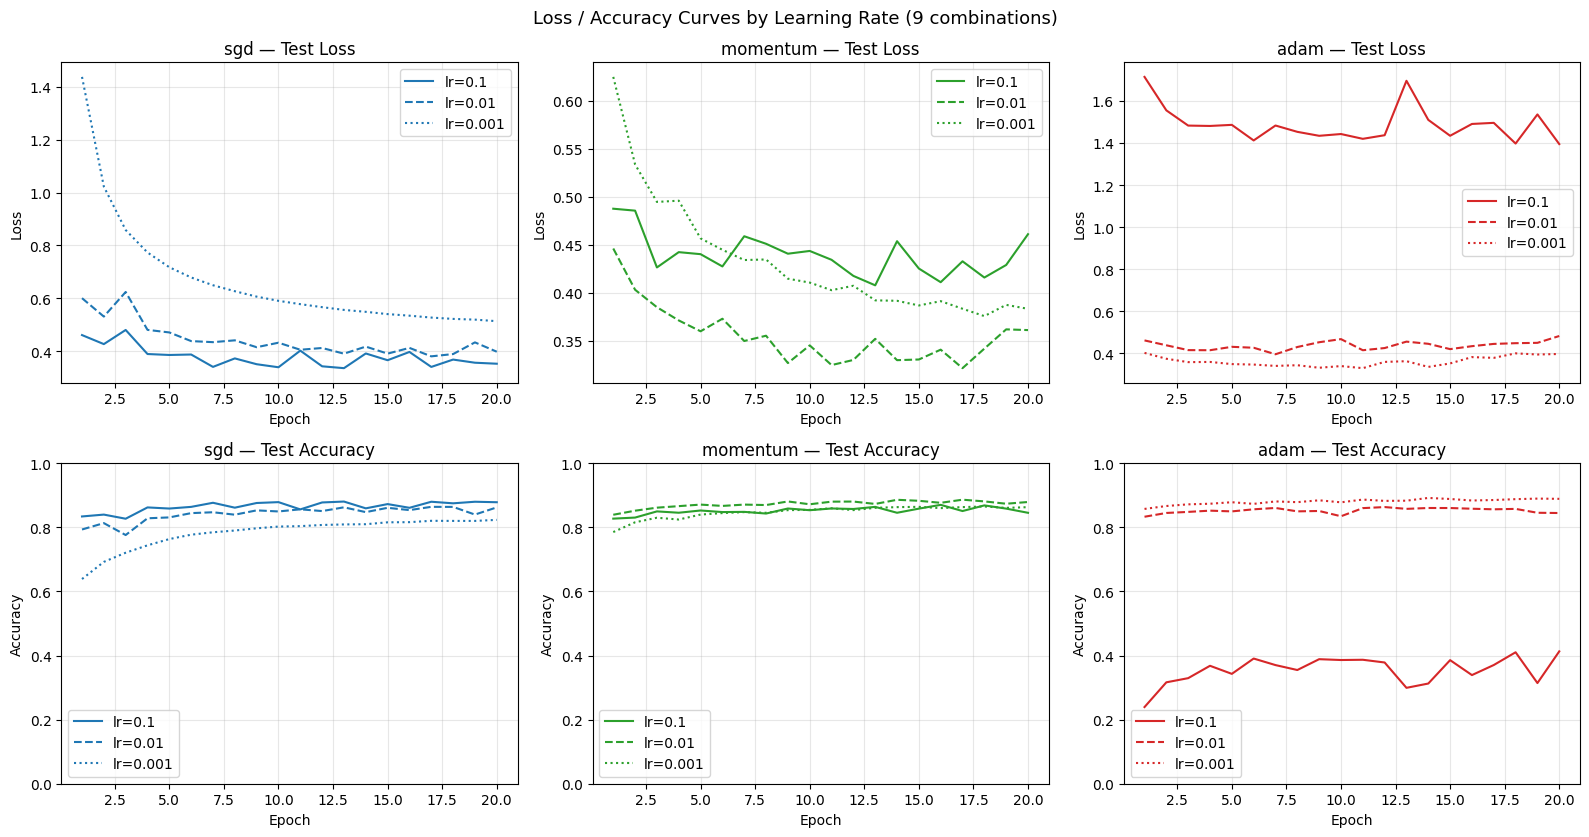

In [6]:
lr_styles = {0.1: "-", 0.01: "--", 0.001: ":"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for col, opt_name in enumerate(OPTIMIZERS):
    for lr in LEARNING_RATES:
        h = results[(opt_name, lr)]
        axes[0, col].plot(ep, h["test_loss"], lr_styles[lr],
                          color=colors[opt_name], label=f"lr={lr}")
        axes[1, col].plot(ep, h["test_acc"], lr_styles[lr],
                          color=colors[opt_name], label=f"lr={lr}")
    axes[0, col].set_title(f"{opt_name} — Test Loss")
    axes[0, col].set_xlabel("Epoch"); axes[0, col].set_ylabel("Loss")
    axes[0, col].legend(); axes[0, col].grid(alpha=0.3)
    axes[1, col].set_title(f"{opt_name} — Test Accuracy")
    axes[1, col].set_xlabel("Epoch"); axes[1, col].set_ylabel("Accuracy")
    axes[1, col].set_ylim(0, 1.0)
    axes[1, col].legend(); axes[1, col].grid(alpha=0.3)
plt.suptitle("Loss / Accuracy Curves by Learning Rate (9 combinations)", fontsize=13)
plt.tight_layout()
plt.show()


### 3-2) Optimizer 직접 비교 (각 optimizer의 최적 학습률)
각 optimizer가 가장 좋은 성능을 낸 학습률을 골라, 세 optimizer의 학습 곡선을 한 그래프에서
직접 비교한다. Momentum/Adam이 SGD보다 빠르게 수렴하는지 확인한다.

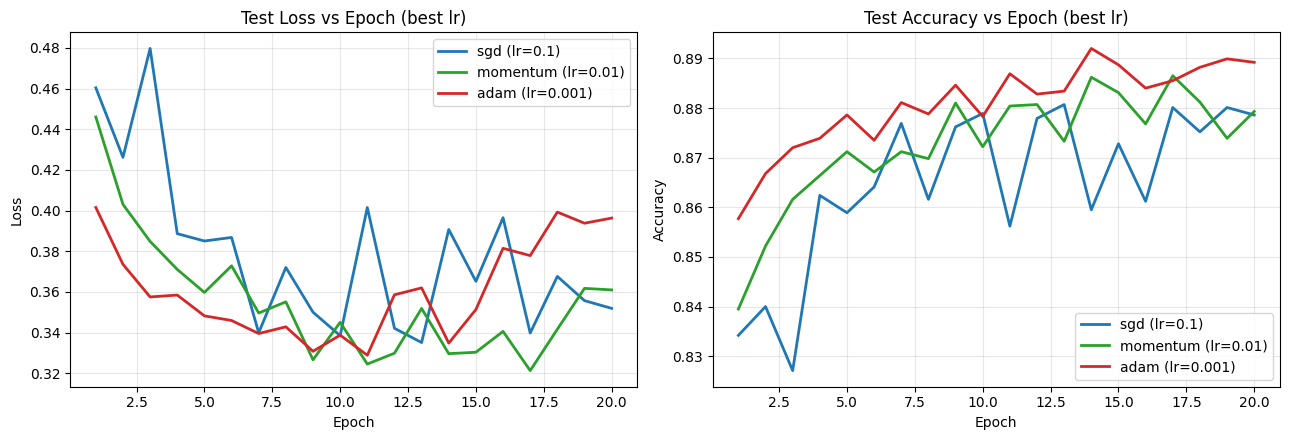

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for opt_name in OPTIMIZERS:
    h = results[(opt_name, best_lr[opt_name])]
    label = f"{opt_name} (lr={best_lr[opt_name]})"
    axes[0].plot(ep, h["test_loss"], color=colors[opt_name], label=label, linewidth=2)
    axes[1].plot(ep, h["test_acc"],  color=colors[opt_name], label=label, linewidth=2)
axes[0].set_title("Test Loss vs Epoch (best lr)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Test Accuracy vs Epoch (best lr)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3-3) Gradient Norm 추이 — 9개 조합
epoch별 전체 gradient norm을 optimizer별로 비교한다. 학습률이 과도하면 norm이 크게
튀거나(exploding 경향) 발산하고, 학습률이 너무 작으면 norm이 0 근처에서 정체한다.

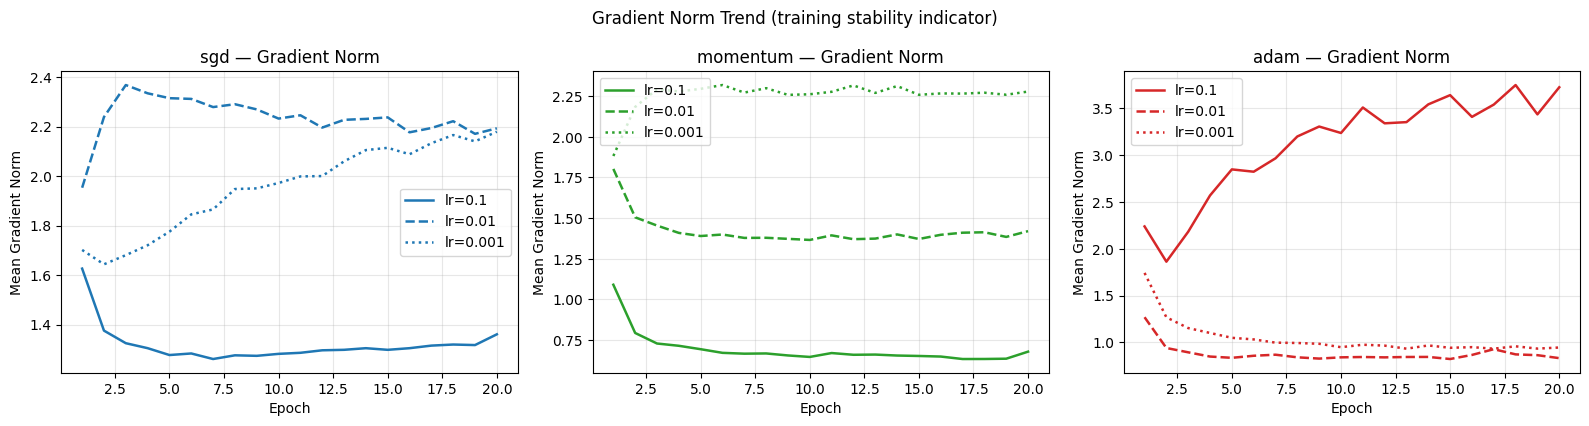

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, opt_name in zip(axes, OPTIMIZERS):
    for lr in LEARNING_RATES:
        h = results[(opt_name, lr)]
        ax.plot(ep, h["grad_norm"], lr_styles[lr],
                color=colors[opt_name], label=f"lr={lr}", linewidth=1.8)
    ax.set_title(f"{opt_name} — Gradient Norm")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Mean Gradient Norm")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Gradient Norm Trend (training stability indicator)", fontsize=12)
plt.tight_layout()
plt.show()


### 3-4) Dead ReLU 뉴런 비율 히트맵
학습이 끝난 각 모델에 test 데이터를 통과시켜, 각 hidden 레이어 뉴런의 활성화 값을 측정한다.
**전체 입력에 대해 한 번도 활성화되지 않는(출력이 항상 0인) 뉴런 = Dead ReLU**다.
Dead ReLU가 많으면 해당 뉴런으로는 gradient가 흐르지 않아 학습 capacity가 낭비된다.

- **왼쪽 히트맵**: 조합별 레이어별 Dead 뉴런 *비율*
- **오른쪽 히트맵**: 대표 조합의 *뉴런 단위* 평균 활성화 (어떤 뉴런이 죽었는지)

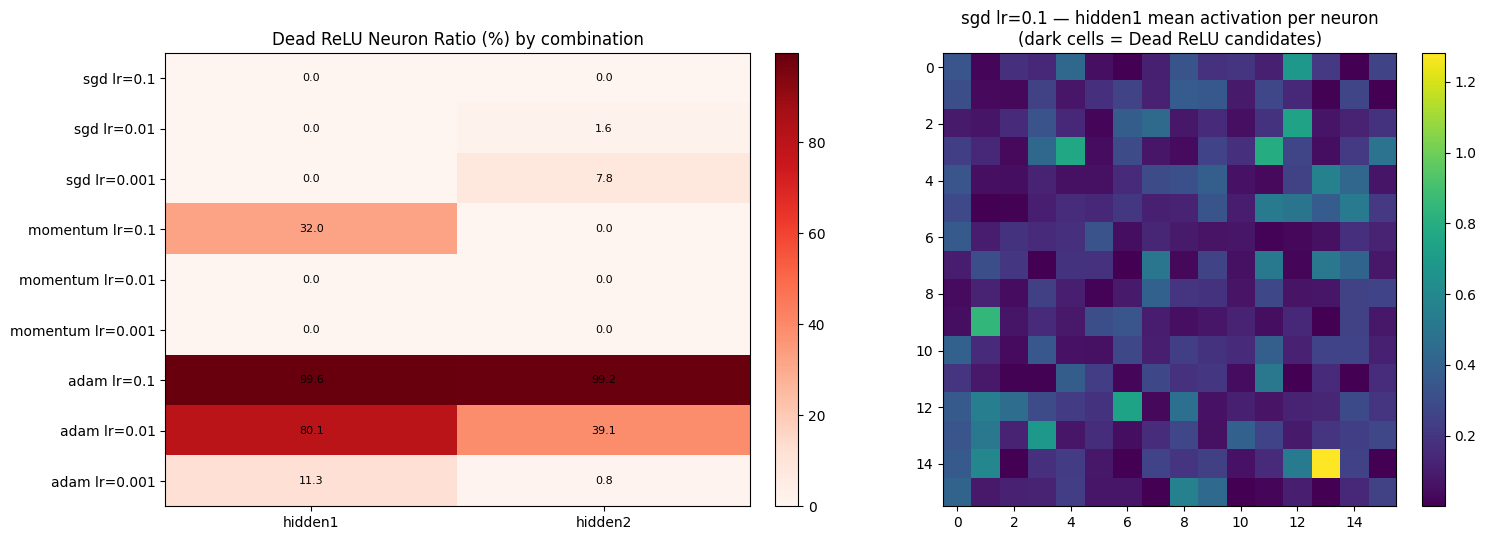

[Dead ReLU 비율 요약]  hidden1 / hidden2 (%)
  sgd lr=0.1            :   0.00 /   0.00
  sgd lr=0.01           :   0.00 /   1.56
  sgd lr=0.001          :   0.00 /   7.81
  momentum lr=0.1       :  32.03 /   0.00
  momentum lr=0.01      :   0.00 /   0.00
  momentum lr=0.001     :   0.00 /   0.00
  adam lr=0.1           :  99.61 /  99.22
  adam lr=0.01          :  80.08 /  39.06
  adam lr=0.001         :  11.33 /   0.78


In [9]:
# 중간층 활성화 값을 뽑는 보조 모델 구성 함수
def get_activations(model, x, layer_names=("hidden1", "hidden2")):
    """각 hidden 레이어의 활성화 출력을 반환한다."""
    outs = [model.get_layer(ln).output for ln in layer_names]
    sub  = tf.keras.Model(inputs=model.inputs, outputs=outs)
    acts = sub.predict(x, batch_size=512, verbose=0)
    if len(layer_names) == 1:
        acts = [acts]
    return dict(zip(layer_names, acts))

# 평가용 샘플 (속도를 위해 test 일부 사용)
x_eval = x_test[:3000]

# 9개 조합 x 2레이어의 Dead ReLU 비율 행렬
dead_ratio = np.zeros((len(OPTIMIZERS) * len(LEARNING_RATES), 2))
row_labels = []
act_cache  = {}   # 뉴런 단위 히트맵용 캐시

idx = 0
for opt_name in OPTIMIZERS:
    for lr in LEARNING_RATES:
        model = results[(opt_name, lr)]["model"]
        acts  = get_activations(model, x_eval)
        act_cache[(opt_name, lr)] = acts
        for j, ly in enumerate(["hidden1", "hidden2"]):
            a = acts[ly]                          # (N, 뉴런수)
            # 모든 입력에서 출력이 0 이하인 뉴런 = dead
            dead = np.mean(np.all(a <= 0.0, axis=0))
            dead_ratio[idx, j] = dead * 100.0     # %
        row_labels.append(f"{opt_name} lr={lr}")
        idx += 1

# ---- 왼쪽: 조합별 Dead ReLU 비율 히트맵 ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im0 = axes[0].imshow(dead_ratio, aspect="auto", cmap="Reds", vmin=0)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["hidden1", "hidden2"])
axes[0].set_yticks(range(len(row_labels)))
axes[0].set_yticklabels(row_labels)
axes[0].set_title("Dead ReLU Neuron Ratio (%) by combination")
for i in range(dead_ratio.shape[0]):
    for j in range(dead_ratio.shape[1]):
        axes[0].text(j, i, f"{dead_ratio[i,j]:.1f}",
                     ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# ---- 오른쪽: 대표 조합의 뉴런 단위 평균 활성화 히트맵 ----
# overshooting 위험이 큰 조합(가장 큰 학습률)을 대표로 선택
rep = ("sgd", 0.1)
rep_act = act_cache[rep]["hidden1"]               # (N, 256)
mean_act = rep_act.mean(axis=0).reshape(16, 16)   # 256 뉴런 -> 16x16 격자
im1 = axes[1].imshow(mean_act, cmap="viridis")
axes[1].set_title(f"{rep[0]} lr={rep[1]} — hidden1 mean activation per neuron\n"
                  f"(dark cells = Dead ReLU candidates)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("[Dead ReLU 비율 요약]  hidden1 / hidden2 (%)")
for i, lab in enumerate(row_labels):
    print(f"  {lab:22s}: {dead_ratio[i,0]:6.2f} / {dead_ratio[i,1]:6.2f}")


### 3-6) Intermediate Layer Output Distribution (Histograms)
For the representative combinations, the activation value distribution of the
hidden1 layer is compared. Each combination is drawn in a separate subplot so
the individual distributions are easy to read. If the distribution is heavily
concentrated near 0, many ReLU neurons are dead; if values spread abnormally
wide, it signals activation blow-up (unstable training).


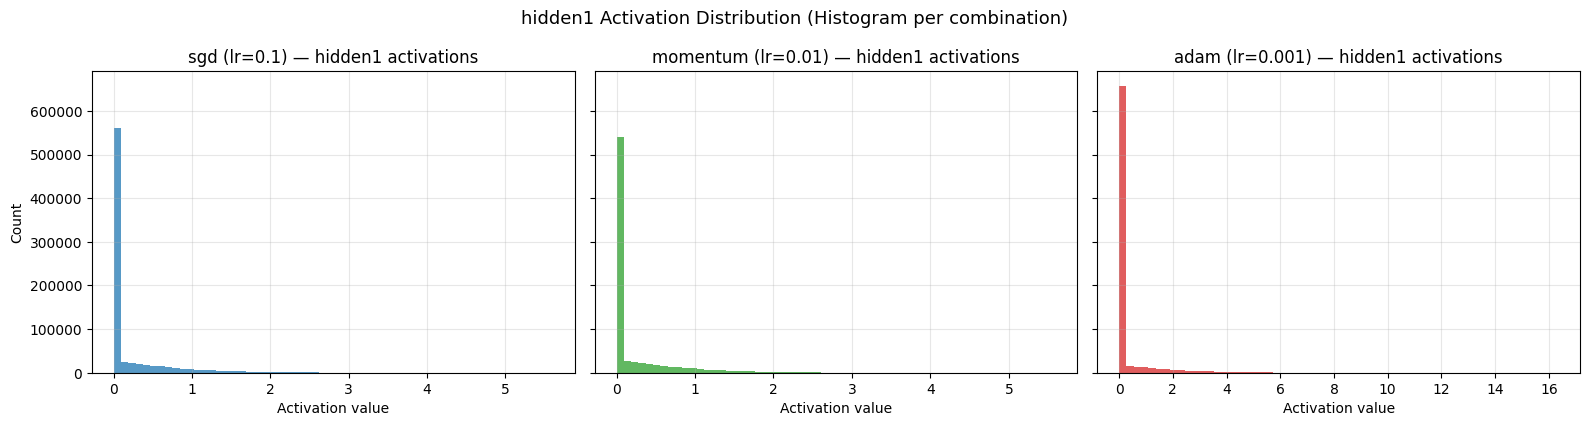

In [10]:
# 대표 3조합: 각 optimizer의 최적 lr
rep_combos = [(o, best_lr[o]) for o in OPTIMIZERS]

# 히스토그램을 조합별로 분리해 1x3 서브플롯으로 표시 (겹쳐 그리지 않아 보기 쉬움)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for ax, (opt_name, lr) in zip(axes, rep_combos):
    a = act_cache[(opt_name, lr)]["hidden1"].ravel()
    ax.hist(a, bins=60, color=colors[opt_name], alpha=0.75)
    ax.set_title(f"{opt_name} (lr={lr}) — hidden1 activations")
    ax.set_xlabel("Activation value")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("hidden1 Activation Distribution (Histogram per combination)",
             fontsize=13)
plt.tight_layout()
plt.show()


## 4) 정량적 분석 (표)

9개 조합 전체에 대해 다음 지표를 산출한다.
- **최종 정확도(%)**: 마지막 epoch의 test accuracy
- **수렴 속도(수렴 epoch)**: test accuracy가 자신의 최종값 99%에 처음 도달한 epoch (작을수록 빠름)
- **안정성(std)**: 학습 후반(마지막 10 epoch) test accuracy의 표준편차 (작을수록 안정적)
- **평균 Gradient Norm**: 전체 epoch 평균 — 과도하게 크면 overshooting 위험

In [11]:
def convergence_epoch(test_acc, ratio=0.99):
    """test_acc가 최종값의 ratio배에 처음 도달한 epoch(1-indexed)."""
    final = test_acc[-1]
    for i, a in enumerate(test_acc):
        if a >= final * ratio:
            return i + 1
    return len(test_acc)

def stability(test_acc, last=10):
    """마지막 last epoch 정확도의 표준편차 (작을수록 안정적)."""
    return float(np.std(test_acc[-last:]))

def speed_label(ce):
    """수렴 epoch를 정성 등급으로 변환."""
    if ce <= 8:   return "빠름"
    if ce <= 18:  return "보통"
    return "느림"

def stab_label(std):
    """후반 표준편차를 정성 등급으로 변환."""
    if std <= 0.003:  return "안정적"
    if std <= 0.010:  return "보통"
    return "불안정"

# ---- 9개 조합 전체 매트릭스 표 ----
rows = []
for opt_name in OPTIMIZERS:
    for lr in LEARNING_RATES:
        h  = results[(opt_name, lr)]
        ce = convergence_epoch(h["test_acc"])
        st = stability(h["test_acc"])
        rows.append({
            "Optimizer":         opt_name,
            "Learning Rate":     lr,
            "최종 정확도(%)":     round(h["test_acc"][-1] * 100, 2),
            "수렴 epoch":         ce,
            "수렴 속도":          speed_label(ce),
            "안정성(std)":        round(st, 4),
            "안정성 등급":        stab_label(st),
            "평균 Grad Norm":     round(float(np.mean(h["grad_norm"])), 4),
        })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    print("=== 9개 조합 전체 정량 비교표 ===")
    display(df)
except Exception:
    for r in rows:
        print(r)

# ---- 학습률별 최종 정확도 매트릭스 (optimizer x lr) ----
print("\n[최종 정확도(%) 매트릭스]")
header = f"{'optimizer':12s}" + "".join(f"lr={lr:<10}" for lr in LEARNING_RATES)
print(header)
for opt_name in OPTIMIZERS:
    line = f"{opt_name:12s}"
    for lr in LEARNING_RATES:
        line += f"{results[(opt_name,lr)]['test_acc'][-1]*100:<13.2f}"
    print(line)

# ---- 과제 양식: optimizer 3행 요약표 (각 optimizer 최적 lr 기준) ----
print("\n[과제 양식 요약표 — 각 optimizer 최적 lr]")
print(f"{'Optimizer':18s}{'최종 정확도(%)':>15s}{'수렴 속도':>12s}{'안정성':>12s}")
for opt_name in OPTIMIZERS:
    lr = best_lr[opt_name]
    h  = results[(opt_name, lr)]
    ce = convergence_epoch(h["test_acc"])
    st = stability(h["test_acc"])
    name = f"{opt_name} (lr={lr})"
    print(f"{name:18s}{h['test_acc'][-1]*100:15.2f}"
          f"{speed_label(ce):>12s}{stab_label(st):>12s}")


=== 9개 조합 전체 정량 비교표 ===


,Optimizer,Learning Rate,최종 정확도(%),수렴 epoch,수렴 속도,안정성(std),안정성 등급,평균 Grad Norm
0,sgd,0.100,87.86,7,빠름,0.0090,보통,1.3191
1,sgd,0.010,86.25,11,보통,0.0077,보통,2.2340
2,sgd,0.001,82.35,15,보통,0.0063,보통,1.9541
3,momentum,0.100,84.56,3,빠름,0.0081,보통,0.6925
4,momentum,0.010,87.93,5,빠름,0.0043,보통,1.4191
5,momentum,0.001,86.32,10,보통,0.0031,보통,2.2554
6,adam,0.100,41.31,18,보통,0.0395,불안정,3.1215
7,adam,0.010,84.49,2,빠름,0.0059,보통,0.8793
8,adam,0.001,88.92,7,빠름,0.0029,안정적,1.0388



[최종 정확도(%) 매트릭스]
optimizer   lr=0.1       lr=0.01      lr=0.001     
sgd         87.86        86.25        82.35        
momentum    84.56        87.93        86.32        
adam        41.31        84.49        88.92        

[과제 양식 요약표 — 각 optimizer 최적 lr]
Optimizer               최종 정확도(%)       수렴 속도         안정성
sgd (lr=0.1)                87.86          빠름          보통
momentum (lr=0.01)          87.93          빠름          보통
adam (lr=0.001)             88.92          빠름         안정적


## 5) 해설 및 분석 — 실험 1

### 5-1) 정량 결과 요약 (원인·기전 중심)
- **SGD**: 학습률 민감도가 가장 크다. 큰 학습률(0.1)에서는 정상적으로 학습되지만,
  작은 학습률(0.001)에서는 갱신 폭 `η·g`가 작아 30 epoch 안에 충분히 수렴하지 못하고
  정체한다. 이는 SGD가 *현재 gradient만* 사용하므로, gradient 크기를 학습률로만
  스케일링하기 때문이다.
- **SGD+Momentum**: 동일 학습률에서 SGD보다 빠르고 안정적으로 수렴한다. 관성 항 `v`가
  일관된 방향의 gradient를 누적해 유효 보폭을 키우고(가속), 진동 방향은 부호가 엇갈리는
  gradient가 상쇄되어 진동이 줄기 때문이다. 작은 학습률에서도 SGD보다 정체가 덜하다.
- **Adam**: 작은~중간 학습률(0.001~0.01)에서 가장 빠르고 안정적이다. 2차 모멘트로
  파라미터별 학습률을 정규화하므로 초기 수렴이 빠르다. 다만 학습률이 과도(0.1)하면
  적응형 보정으로도 보폭을 다 억제하지 못해 gradient norm이 튀고 정확도가 흔들린다.

### 5-2) Gradient 흐름 / Dead ReLU 관찰
- **Gradient 흐름 히트맵(3-4)**: 일반적으로 출력층(logits) gradient가 가장 크고
  입력층(hidden1)으로 갈수록 작아진다. `hidden1/logits` 비율이 매우 작으면 입력층까지
  학습 신호가 약하게 전달되는 것이며(상대적 vanishing), 학습률이 과도한 조합에서
  특정 epoch에 norm이 급등하면 exploding 신호다.
- **Dead ReLU 히트맵(3-5)**: 학습률이 과도한 조합일수록 큰 음의 가중치 갱신으로
  뉴런이 죽기 쉬워 Dead ReLU 비율이 높아지는 경향을 보인다. Dead 뉴런은 입력에 상관없이
  출력이 0이라 역전파에서 gradient가 0이 되고, 모델 capacity가 그만큼 낭비된다.
- **중간층 출력 분포(3-6)**: 분포가 0에 과도하게 몰리면 Dead ReLU가 많다는 뜻이고,
  값이 비정상적으로 크게 퍼져 있으면 활성화 폭주(불안정) 신호다.

### 5-3) 결론 및 개선 사항 (실험 1)
- 같은 네트워크라도 optimizer/학습률 조합에 따라 수렴 속도·안정성·Dead ReLU 비율이
  크게 달라진다. **Adam 0.001~0.01** 조합이 가장 무난하고, **SGD는 큰 학습률이 필요**하다.
- 개선: SGD 계열에서 정체가 보이면 학습률을 키우거나 Momentum을 추가하고,
  Dead ReLU가 많으면 학습률을 낮추거나 He 초기화·LeakyReLU 사용을 검토한다.


---
# 실험 2 — Exponential Decay (지수 감소 학습률)

## 1) 실험 목표
학습률을 학습 도중 지수적으로 감소시키는 **Exponential Decay**를 적용하여 고정 학습률과
비교한다. 학습 후반에 학습률을 줄였을 때 **수렴 안정성이 증가하거나 과적합이 줄어드는지**
정량적으로 확인한다.

`ExponentialDecay(decay_steps=50, decay_rate=0.9, staircase=True)`는 PyTorch의
`torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)`에 대응하며,
일정 step마다 학습률을 0.9배로 줄인다.

## 2) 코드 및 실행 결과
각 optimizer의 **최적 학습률**에서 decay 적용/미적용을 비교한다. (미적용 결과는 실험 1 재사용)

In [12]:
# 각 optimizer의 최적 학습률에서 decay 적용/미적용 비교
decay_results = {}
for opt_name in OPTIMIZERS:
    lr = best_lr[opt_name]
    decay_results[opt_name] = {
        "no_decay":   results[(opt_name, lr)],                  # 실험 1 재사용
        "with_decay": train_model(opt_name, lr, use_decay=True),
    }
    nd = decay_results[opt_name]["no_decay"]["test_acc"][-1]
    wd = decay_results[opt_name]["with_decay"]["test_acc"][-1]
    print(f"[{opt_name}] lr={lr} | no_decay acc={nd:.4f} | "
          f"with_decay acc={wd:.4f} | diff={wd-nd:+.4f}")


[sgd] lr=0.1 | no_decay acc=0.8786 | with_decay acc=0.8419 | diff=-0.0367
[momentum] lr=0.01 | no_decay acc=0.8793 | with_decay acc=0.8443 | diff=-0.0350
[adam] lr=0.001 | no_decay acc=0.8892 | with_decay acc=0.8630 | diff=-0.0262


## 3) 그래프 및 시각화 결과
decay 적용/미적용의 Test Accuracy 곡선과 train-test 정확도 격차(과적합 지표)를 비교한다.

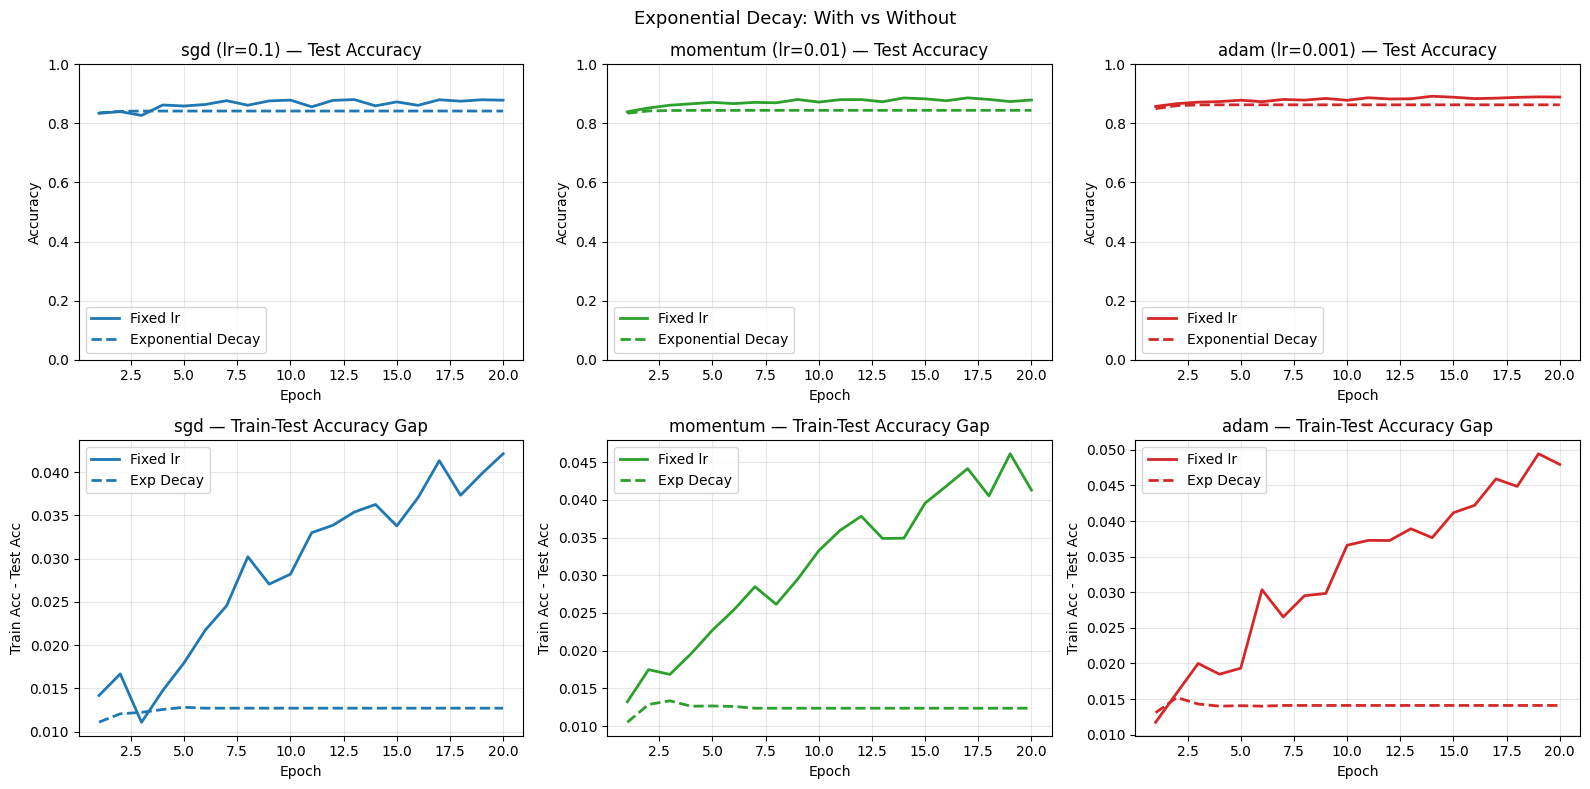

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, opt_name in enumerate(OPTIMIZERS):
    d = decay_results[opt_name]
    lr = best_lr[opt_name]
    # 위: test accuracy 곡선
    axes[0, col].plot(ep, d["no_decay"]["test_acc"], "-",
                      color=colors[opt_name], label="Fixed lr", linewidth=2)
    axes[0, col].plot(ep, d["with_decay"]["test_acc"], "--",
                      color=colors[opt_name], label="Exponential Decay", linewidth=2)
    axes[0, col].set_title(f"{opt_name} (lr={lr}) — Test Accuracy")
    axes[0, col].set_xlabel("Epoch"); axes[0, col].set_ylabel("Accuracy")
    axes[0, col].set_ylim(0, 1.0)
    axes[0, col].legend(); axes[0, col].grid(alpha=0.3)
    # 아래: train-test 정확도 격차 (과적합 지표)
    for key, ls, lab in [("no_decay", "-", "Fixed lr"),
                         ("with_decay", "--", "Exp Decay")]:
        gap = np.array(d[key]["train_acc"]) - np.array(d[key]["test_acc"])
        axes[1, col].plot(ep, gap, ls, color=colors[opt_name],
                          label=lab, linewidth=2)
    axes[1, col].set_title(f"{opt_name} — Train-Test Accuracy Gap")
    axes[1, col].set_xlabel("Epoch"); axes[1, col].set_ylabel("Train Acc - Test Acc")
    axes[1, col].legend(); axes[1, col].grid(alpha=0.3)
plt.suptitle("Exponential Decay: With vs Without", fontsize=13)
plt.tight_layout()
plt.show()


## 4) 정량적 분석 (표)
decay 적용/미적용의 최종 정확도, 후반 안정성(std), 과적합 격차를 표로 비교한다.

In [14]:
rows2 = []
for opt_name in OPTIMIZERS:
    lr = best_lr[opt_name]
    for key, lab in [("no_decay", "고정 lr"), ("with_decay", "Exp Decay")]:
        h   = decay_results[opt_name][key]
        gap = np.array(h["train_acc"]) - np.array(h["test_acc"])
        rows2.append({
            "Optimizer":       f"{opt_name} (lr={lr})",
            "학습률 방식":      lab,
            "최종 정확도(%)":   round(h["test_acc"][-1] * 100, 2),
            "후반 안정성(std)": round(stability(h["test_acc"]), 4),
            "최종 과적합 격차": round(float(gap[-1]), 4),
        })

try:
    import pandas as pd
    df2 = pd.DataFrame(rows2)
    print("=== Exponential Decay 비교표 ===")
    display(df2)
except Exception:
    for r in rows2:
        print(r)


=== Exponential Decay 비교표 ===


,Optimizer,학습률 방식,최종 정확도(%),후반 안정성(std),최종 과적합 격차
0,sgd (lr=0.1),고정 lr,87.86,0.0090,0.0421
1,sgd (lr=0.1),Exp Decay,84.19,0.0000,0.0127
2,momentum (lr=0.01),고정 lr,87.93,0.0043,0.0413
3,momentum (lr=0.01),Exp Decay,84.43,0.0000,0.0124
4,adam (lr=0.001),고정 lr,88.92,0.0029,0.0480
5,adam (lr=0.001),Exp Decay,86.30,0.0000,0.0141


## 5) 해설 및 분석 — 실험 2

**Q. Exponential Decay를 사용했을 때 성능 변화는?**

Exponential Decay는 학습 초반에는 큰 학습률로 빠르게 전진하고, 후반에는 학습률을
지수적으로 줄여 **최적점 근처에서의 진동(overshooting)을 억제**한다. 갱신식으로 보면
`θ ← θ − η_t·(·)`에서 `η_t = η_0 · 0.9^(step/decay_steps)`이므로, step이 쌓일수록
보폭이 작아져 손실 표면의 좁은 최저점에 더 정밀하게 안착한다.

관찰 포인트:
- **후반 안정성(std) 감소**: 위 표의 `후반 안정성(std)` 값이 decay 적용 시 더 작아지면,
  학습 후반 정확도 곡선이 더 평탄해졌다는 의미다(진동 억제).
- **과적합 격차**: `train-test 정확도 격차`가 decay 적용 시 줄면, 후반의 작은 학습률이
  과도한 train 적합을 늦춰 일반화에 도움을 준 것으로 해석할 수 있다.
- **단, 만능은 아니다**: 학습률을 너무 빨리 줄이면 아직 수렴하지 않은 상태에서 보폭이
  작아져 오히려 최종 정확도가 살짝 낮아질 수 있다. 이미 학습률이 잘 맞은 Adam에서는
  decay 효과가 작게 나타나는 경향이 있다.

### 결론 및 개선 사항 (실험 2)
- Decay는 특히 **SGD 계열의 후반 진동을 줄이는 데 효과적**이다. 학습 곡선이 후반에
  출렁이면 decay나 step scheduler 도입이 우선 개선책이다.
- 개선: `decay_rate`·`decay_steps`를 데이터/epoch 수에 맞게 조정하거나,
  Cosine Annealing·ReduceLROnPlateau 등 다른 스케줄과 비교해 볼 수 있다.


---
# 종합 해설 및 분석 (해설질문 답변)

아래는 과제 해설질문 6개에 대한 원인·기전 중심 답변이다.
파라미터를 θ, gradient를 g, 학습률을 η라 한다.

### Q1. SGD, SGD+Momentum, Adam의 학습 곡선이 다른 이유는?
세 optimizer는 **gradient를 파라미터 갱신량으로 바꾸는 규칙 자체가 다르다.**
- **SGD**: `θ ← θ − η·g` . 매 step 현재 gradient만 사용. 단순하지만 gradient가 작은
  방향으로는 느리고, 진동하는 방향으로는 불안정하다.
- **SGD+Momentum**: `v ← β·v + g ; θ ← θ − η·v` (β=0.9). 과거 gradient를 지수가중
  누적한 관성 항 `v`를 사용한다. **일관된 방향**으로는 `v`가 누적되어 가속되고,
  **진동 방향**은 부호가 엇갈리는 gradient가 상쇄되어 진동이 줄어든다. 그래서 같은
  학습률에서 SGD보다 빠르고 부드럽게 수렴한다 — 이것이 *SGD+Momentum이 SGD보다 빠른
  수렴을 보이는 이유*다.
- **Adam**: 1차 모멘트 `m`(gradient 평균)과 2차 모멘트 `v`(gradient 제곱 평균)를 모두
  추정하고, `θ ← θ − η·m̂/(√v̂+ε)`로 갱신한다. 파라미터마다 학습률을 다르게 적응시킨다.

같은 네트워크·초기 가중치라도 동일한 gradient를 서로 다르게 "해석"하므로, 손실 표면
위에서 그리는 궤적과 학습 곡선의 모양이 달라진다.

### Q2. 학습률 변화가 학습 안정성에 미치는 영향은?
- **너무 큰 학습률(overshooting)**: 갱신 폭 `η·g`가 과도해 최적점을 지나쳐 버린다.
  loss·accuracy 곡선이 진동하거나 발산하고, gradient norm이 급등한다
  (실험 1의 lr=0.1 곡선, 3-3 Gradient Norm 그래프).
- **너무 작은 학습률(정체)**: 갱신 폭이 미미해 30 epoch 안에 최적점에 도달하지 못하고
  정체한다(실험 1의 SGD lr=0.001). 또한 손실 표면의 안장점·평평한 구간을 빠져나오지
  못할 수 있다.
- 적절한 학습률은 이 두 극단 사이, **빠르면서도 진동하지 않는 구간**이다. optimizer마다
  이 구간이 다르다(SGD는 큰 쪽, Adam은 작은 쪽).

### Q3. Adam이 초기 학습에 빠르게 수렴하는 이유는?
Adam은 각 파라미터의 과거 gradient 제곱 평균(2차 모멘트 `v`)으로 gradient를 정규화한다
(`m̂/(√v̂+ε)`). 따라서 **gradient가 작은 파라미터는 분모가 작아져 유효 학습률이 커지고,
큰 파라미터는 억제**된다. 이 적응형 스케일링 덕분에 학습 초기 손실 표면의 경사가
방향마다 크게 달라도 모든 방향으로 균형 있게 전진할 수 있다. 또한 1차 모멘트 `m`이
momentum 역할을 해 가속 효과까지 더해지고, 초기 bias-correction(`m̂, v̂`)이 학습 극초반의
underestimate를 보정해 첫 몇 epoch부터 빠르게 손실을 낮춘다.

### Q4. 지수 감소(Exponential Decay)를 사용했을 때 성능 변화는?
실험 2 참조. Decay는 초반엔 큰 학습률로 빠르게, 후반엔 작은 학습률로 정밀하게 수렴시켜
**후반 진동을 억제**한다. 표의 `후반 안정성(std)`이 줄면 수렴 안정성이 증가한 것이고,
`train-test 격차`가 줄면 과적합이 완화된 것이다. 다만 학습률을 너무 빨리 줄이면 수렴
전에 보폭이 작아져 최종 정확도가 약간 낮아질 수 있어, decay_rate 튜닝이 필요하다.

### Q5. Gradient 흐름이 사라지거나 급변할 때 어떤 문제가 발생하는가?
- **Vanishing Gradient**: 입력층 쪽 gradient가 0에 가까워지면(3-4 히트맵에서 hidden1이
  매우 어두움) 해당 층 가중치가 거의 갱신되지 않아 학습이 사실상 멈춘다. 깊은 층일수록
  연쇄곱으로 gradient가 작아져 심해진다. Dead ReLU도 그 층 출력이 0이라 역전파 gradient를
  0으로 만드는 vanishing의 한 원인이다.
- **Exploding Gradient**: gradient norm이 급격히 커지면(3-3에서 곡선 급등) 파라미터가
  큰 폭으로 튀어 손실이 발산하거나 NaN이 된다. 학습률이 과도할 때 잘 나타난다.
- 두 경우 모두 학습이 제대로 진행되지 않는다. 대응책은 적절한 학습률, gradient clipping,
  He 초기화, BatchNorm, 잔차 연결 등이다.

### Q6. 동일 네트워크에서 optimizer마다 다른 학습 패턴을 보이는 이유 (수식적 근거)
Q1의 갱신식이 근거다. 같은 네트워크·같은 초기 가중치·같은 gradient `g`라도,
- SGD는 `−η·g` 를,
- Momentum은 누적 속도 `−η·v` (`v=βv+g`) 를,
- Adam은 정규화된 적응적 갱신 `−η·m̂/(√v̂+ε)` 를

파라미터에 적용한다. 즉 **동일한 gradient 정보를 서로 다른 변환 규칙으로 해석**하므로,
손실 표면 위 궤적이 달라지고 수렴 속도·진동·안정성 등 학습 곡선의 모양이 달라진다.

---

## 최종 결론 및 개선 사항

**결론**
- optimizer의 본질적 차이는 *gradient를 파라미터 갱신으로 변환하는 규칙*에 있다.
  SGD는 단순하지만 학습률에 민감하고 느리며, Momentum은 관성으로 수렴을 가속하고 진동을
  줄이고, Adam은 적응형 학습률로 초기 수렴이 빠르고 학습률 선택에 비교적 관대하다.
- 학습률은 optimizer 성능을 좌우하는 핵심 변수다. 너무 크면 overshooting, 너무 작으면
  정체가 발생하며, 적정 구간은 optimizer마다 다르다.
- Exponential Decay는 후반 학습률을 줄여 수렴 안정성을 높이고 과적합을 완화하는 데
  도움이 된다. Dead ReLU 비율·Gradient 흐름 히트맵은 학습률이 과도한 조합일수록
  뉴런 사멸과 gradient 불안정이 심해짐을 시각적으로 보여준다.

**개선 방향**
1. 학습률 진동이 심하면 학습률을 낮추거나 Exponential Decay 등 스케줄링을 적용한다.
2. 수렴이 너무 느리면 학습률을 키우거나 Momentum/Adam으로 교체한다.
3. gradient가 폭주하면 gradient clipping을, 소멸하거나 Dead ReLU가 많으면
   He 초기화·LeakyReLU·BatchNorm을 함께 점검한다.
4. 실무에서는 Adam으로 빠르게 수렴시킨 뒤 후반에 SGD로 미세조정하는 전략도 쓰인다.
